In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime,timedelta
from matplotlib.offsetbox import AnchoredText#关于修改text位置的
from tqdm import tqdm

#计算任意地球上多边形面积
import os
import psutil
from sklearn.neighbors import BallTree
proj =ccrs.NorthPolarStereo(central_longitude=15)
from scipy.interpolate import UnivariateSpline#三次样条平滑
from scipy.interpolate import griddata
import ast
import matplotlib as mpl
import matplotlib.path as mpath
import warnings
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks
import warnings
import tslearn
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans
import seaborn as sns
import cmaps
import json
import shutil
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde
import warnings
warnings.simplefilter('ignore')
from scipy import stats

d:\anaconda\envs\tslearn\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [2]:
result_file = os.path.join(r'X:\time_cluster', 'feature_combination_results.json')
with open(result_file, 'r', encoding='utf-8') as f:
    results = json.load(f)
feature_fraction_df = pd.DataFrame(results).sort_values('major_fraction',ascending=False).reset_index(drop=True)
feature_fraction_df

,features,feature_ids,feature_ids_str,major_fraction
0,"[LPV850, RH, cape, latent_release, theta_trop,...","[15, 9, 13, 11, 14, 0, 7]",0_7_9_11_13_14_15,0.693196
1,"[LPV850, RH, latent_release, q, theta_trop, th...","[15, 9, 11, 5, 14, 0, 7]",0_5_7_9_11_14_15,0.693115
2,"[LPV850, RH, cape, latent_release, theta_trop,...","[15, 9, 13, 11, 14, 0]",0_9_11_13_14_15,0.693051
3,"[LPV850, RH, cape, latent_release, pbh, theta_...","[15, 9, 13, 11, 1, 14, 0]",0_1_9_11_13_14_15,0.692987
4,"[LPV850, RH, latent_release, pbh, theta_trop, ...","[15, 9, 11, 1, 14, 0]",0_1_9_11_14_15,0.692313
...,...,...,...,...
3177,"[LPV850, latent_heat, sensible_heat, theta_tro...","[15, 8, 12, 14, 7, 2]",2_7_8_12_14_15,0.559410
3178,"[LPV850, theta_SST_500, theta_trop, thickness_...","[15, 4, 14, 7, 6, 2]",2_4_6_7_14_15,0.559360
3179,"[LPV850, theta_SST_500, theta_trop, thickness_...","[15, 4, 14, 7, 2]",2_4_7_14_15,0.558402
3180,"[LPV850, RH, sensible_heat, theta_trop, thickn...","[15, 9, 12, 14, 7, 2]",2_7_9_12_14_15,0.555707


In [3]:
datasets = pd.read_excel(r'D:\Desktop\PLs_feature\feature_track\features_track.xlsx').set_index('ID')

In [4]:
# PMCs_ID = np.loadtxt(r"D:\Desktop\PLs_feature\climate\PMCs_climate.txt")
# radius = 150
# track_folder = fr'X:\features\features{radius}km'
# result = []
# for file in tqdm(os.listdir(track_folder)):
#     result.append(pd.read_excel(os.path.join(track_folder,file)))
# ERA5_features = pd.concat(result,axis=0).set_index('point_index').sort_index()
# ERA5_features['LHRR'] = ERA5_features['tp']*787
# ERA5_features = ERA5_features.drop(columns=['tp','isolated_area_path', 'original_vort_line','lon','vort_min_line', 'lat','core_r', 'iso_r','slp_dis', 'slp_lon', 'slp_lat', 'ano150km', 'slp'])
# ERA5_features = ERA5_features.loc[ERA5_features.ID.isin(PMCs_ID)]
# ERA5_features.reset_index().to_excel(r"X:\ERA5_features_climate.xlsx",index=False)

In [5]:
var_name_dict = {'CAO_depth':'CAODepth','theta_trop':'TropTheta','theta_SST_500':'CAO500','theta_SST_700':'CAO700',
                 'peak_value':'Vort850','vort10':'Vort10m','ano110':'SLPDepth','iso_r':'Radius',
                 'max_wind_inborder':'Vmax10m','vort_adv':'PVA','latent_release':'LHRR','LPV850':'LPV',
                 'thickness':'Thickness','thickness_gra':'GrdThick','shear_angle500':'ShearAngle',
                 'shear_strength500':'ShearStrength','sensible_heat':'SHF','latent_heat':'LHF',
                 'pbh':'PBLH','q':'Q','siconc':'SIC','sst':'SST','thickness_adv':'ThickAdv','q_adv':'QAdv',
                 'wind500':'V500','wind925':'V925','cape':'CAPE','lifetime':'Lifetime'
                 }

In [6]:
PMCs_ID = np.loadtxt(r"D:\Desktop\PLs_feature\climate\PMCs_climate.txt")
ERA5_stage = pd.read_excel(r"X:\fraction0.9\ERA5_tracks_satge.xlsx",usecols=['point_index','stage','max_wind_inborder','ID'])
ERA5_stage = ERA5_stage.set_index('point_index')
ERA5_stage = ERA5_stage.loc[ERA5_stage.ID.isin(PMCs_ID)]
ERA5_features = pd.read_excel(r"X:\ERA5_features_climate.xlsx").set_index('point_index')
ERA5_features = ERA5_features.loc[ERA5_stage.index]
ERA5_features[['max_wind_inborder','stage']] = ERA5_stage[['max_wind_inborder','stage']]

In [7]:
ERA5_features = ERA5_features.rename(columns=var_name_dict)
area_features = ['Vmax10m','CAODepth','Q','GrdThick','PBLH', 'SIC', 'SST','CAO500', 'CAO700',  'LHRR', 'TropTheta', 
                    'LPV', 'div500', 'div850', 'Vort850', 'PVA', 'N2','RH','ShearAngle','ThickAdv', 'QAdv','V500','V925',
                'Thickness',  'SHF', 'LHF', 'CAPE','GrdSKT']

In [8]:
#平滑
record = []
for ID in tqdm(ERA5_features.ID.unique()):
    track = ERA5_features.loc[ERA5_features['ID']==ID,area_features].copy()
    record.append(track.rolling(window=3, min_periods=2, center=True).mean())#min_periods: 窗口中最少需要的非 NaN 值数量，默认与窗口大小一致。
smooth_features = pd.concat(record,axis=0)
smooth_features[['ID','stage']] = ERA5_features[['ID','stage']]
smooth_features

100%|██████████| 4882/4882 [01:06<00:00, 73.35it/s]


,Vmax10m,CAODepth,Q,GrdThick,PBLH,SIC,SST,CAO500,CAO700,LHRR,...,QAdv,V500,V925,Thickness,SHF,LHF,CAPE,GrdSKT,ID,stage
point_index,,,,,,,,,,,,,,,,,,,,,
0,NaN,301.227591,0.909144,25.579795,1009.493756,1.058285,274.820746,-12.105805,-0.839726,108.054010,...,-0.682608,14.332660,8.379356,5038.591225,297.737845,190.105227,15.531240,6.158068,1,1
1,NaN,305.461323,0.914504,26.239954,1022.388603,0.930999,274.853819,-11.923273,-0.680445,114.935055,...,-0.853552,14.222611,8.360789,5037.535032,282.580856,183.619479,16.075314,5.931359,1,1
2,NaN,314.701190,0.909821,27.767741,1057.414087,0.740692,274.880451,-11.597239,-0.455959,133.661486,...,-1.184392,14.187276,8.544275,5034.222259,269.285696,173.888476,16.844025,5.496946,1,1
3,13.730000,324.324755,0.929802,28.616511,1087.271794,0.484498,274.929476,-11.188174,-0.235729,147.091536,...,-1.544970,14.209882,8.870014,5033.707704,265.656870,165.002542,17.589588,4.668197,1,1
4,14.053333,331.030689,0.936426,29.935896,1121.005636,0.355590,274.945427,-10.829328,-0.102811,162.349717,...,-1.950127,14.523967,9.349026,5032.194323,280.140565,164.201950,18.854709,4.061902,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022498,NaN,135.359039,0.953931,27.826395,631.615926,41.915426,273.833188,-5.070180,3.470367,148.139445,...,-0.133475,10.835698,7.362690,5007.721561,281.251675,235.045744,9.857289,14.450645,50988,8
1022499,NaN,144.469847,0.953330,27.683046,622.581970,40.078999,274.037678,-4.497956,3.643592,165.161385,...,-0.090045,10.580636,7.235054,5008.240217,291.288331,246.982303,12.589984,14.637567,50988,9
1022500,NaN,143.285632,0.963592,27.823490,602.959473,40.078999,274.037678,-3.996829,3.568175,150.810818,...,0.113295,10.687499,7.232390,5009.088296,248.906164,217.089423,14.527475,14.853357,50988,9


In [9]:
smooth_features = ERA5_features.copy()

In [10]:
stage_num = 9
feature_stage = smooth_features.groupby(['ID','stage'])[area_features].mean().reset_index()
stage_count = feature_stage.groupby('ID')['stage'].nunique()
feature_stage = feature_stage.loc[feature_stage.ID.isin(stage_count[stage_count==stage_num].index)].sort_values(by=['ID','stage'])
feature_stage

,ID,stage,Vmax10m,CAODepth,Q,GrdThick,PBLH,SIC,SST,CAO500,...,ShearAngle,ThickAdv,QAdv,V500,V925,Thickness,SHF,LHF,CAPE,GrdSKT
0,1,1,13.730000,315.085890,0.921539,27.401825,1056.160579,0.714013,274.885984,-11.555226,...,32.039882,1.254184,-1.200025,14.258994,8.673751,5035.661112,278.489260,175.043616,16.766249,5.264146
1,1,2,16.238333,341.433909,0.940791,35.410849,1178.792355,0.150683,275.021468,-10.089685,...,28.330664,0.572943,-4.176095,15.503496,10.713946,5026.931099,376.832352,203.164087,20.335691,2.531699
2,1,3,18.875000,357.594653,0.867953,45.080501,1220.231745,0.000000,274.515163,-10.393317,...,32.731742,-9.644566,-6.487017,16.887370,13.283898,5008.079001,443.712761,271.684585,16.161122,1.774703
3,1,4,20.728000,339.634366,0.864817,48.324214,1183.862968,0.295668,273.467624,-11.189489,...,40.096313,-14.893456,-3.775194,14.596944,14.569940,5006.938760,409.153563,238.888911,13.020853,1.888955
4,1,5,20.876667,317.257120,0.858826,54.475552,1166.064386,4.566661,272.723363,-10.776906,...,71.129994,-1.203476,1.181728,11.336769,16.266627,4997.823777,490.372261,223.398093,13.332215,4.245859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41843,50970,5,34.760000,157.909597,2.006674,72.089916,1611.166691,12.090711,276.018200,-14.591978,...,102.387578,46.392617,20.447968,19.676816,35.382059,5212.746933,633.822441,564.440040,14.989196,5.502474
41844,50970,6,30.361250,257.563653,1.837478,45.722138,1560.917348,0.785585,277.293441,-8.581647,...,130.667449,7.427421,-0.704898,14.542658,23.495805,5161.042174,399.101311,414.334718,30.178996,4.653836
41845,50970,7,21.807000,285.514375,2.096825,24.581891,1261.548831,0.000000,278.898787,-5.181822,...,126.218332,4.046613,2.378349,10.319680,18.323996,5173.643683,192.719398,298.198382,27.148555,0.857609
41846,50970,8,17.117000,149.721818,2.311731,16.618948,1140.897059,0.000000,278.462605,-6.603440,...,34.614731,-4.551268,-1.753610,19.664137,16.656740,5208.798933,122.811257,232.240943,24.415319,4.024421


In [11]:
def sample_standardize_group(df):
    # 计算该样本的均值和标准差
    sample_mean = df.mean(axis=0)
    sample_std = df.std(axis=0)
    # 标准化
    df_standardized = (df - sample_mean) / sample_std
    return df_standardized

In [12]:
class_folder = r'X:\classes'
folder = os.path.join(class_folder,'original')
all_class_names = [i.split('.')[0] for i in os.listdir(folder)]
class_dict = {}
for name in all_class_names:
    class_dict[name] = np.loadtxt(os.path.join(folder,name+'.txt')).astype('int')

In [13]:
#标准化
#1 ['PBLH', 'RH', 'Thickness', 'LPV']
'''
for seed in tqdm(range(100)):
    candidate_columns = ['Thickness','TropTheta', 'LPV','PBLH','PVA','CAODepth','LHRR','CAO500','GrdThick','ThickAdv',  'SHF', 'LHF','RH','ShearAngle', 'N2', 'SST']
    chosed_columns  = ['LPV', 'LHRR', 'TropTheta', 'Thickness',  'CAPE','RH'] 
    #chosed_columns = 
    scaler = TimeSeriesScalerMeanVariance()
    # features_standardized = feature_stage.groupby('ID')[chosed_columns].apply(sample_standardize_group).reset_index(drop=True)
    # time_series = features_standardized.values.reshape(-1,stage_num,len(chosed_columns))
    # X_normalized = time_series.copy()
    time_series = feature_stage[chosed_columns].values.reshape(-1,stage_num,len(chosed_columns))
    # 按每个时间点做均值和方差归一化
    X_normalized = scaler.fit_transform(time_series) 
    X_normalized[np.isnan(X_normalized)] = 0
    n_clusters = 4
    model = TimeSeriesKMeans(
        n_clusters=n_clusters,
        metric="euclidean",  # 使用动态时间规整
        n_init=5,      # 用不同质心初始值运行次数，增加以避免局部最优
        random_state=seed # 设置随机种子保证结果可重现
    )
    # 执行聚类
    labels = model.fit_predict(X_normalized)
    # 获取每个样本所属的簇标签
    labels = model.labels_  # 或者使用之前 fit_predict 返回的 labels
    # 获取每个簇的质心，形状为 (n_clusters, n_timestamps, n_features)
    #----------------------------------------------------------
    cluster_centers = model.cluster_centers_
    unique_IDs = np.sort(np.unique(feature_stage.ID.values))
    series_dict = {}
    for cluster_idx in np.unique(labels):
        cluster_mask = (labels == cluster_idx)
        series_dict[cluster_idx] = unique_IDs[cluster_mask]
    series_map = pd.DataFrame(index=class_dict.keys(),columns=series_dict.keys())
    for index in class_dict.keys():
        for column in series_dict.keys():
            series_map.loc[index,column] = len(np.intersect1d(class_dict[index],series_dict[column]))
    series_map = np.round(series_map/(series_map.sum(axis=1).values.reshape(-1,1)))
    major_fraction = series_map.apply(lambda row: sum(row.values[np.argsort(row)][-2:]), axis=1).mean()
    series_map = pd.DataFrame(index=class_dict.keys(),columns=series_dict.keys())
    for index in class_dict.keys():
        for column in series_dict.keys():
            series_map.loc[index,column] = len(np.intersect1d(class_dict[index],series_dict[column]))
    series_map = np.round(series_map/(series_map.sum(axis=1).values.reshape(-1,1)))
    fig, ax = plt.subplots(figsize=(10, 8))
    f = sns.heatmap(data=series_map.astype('float'),
                cmap=cmaps.MPL_RdBu_r,
                annot=True,#图中数字文本显示
                annot_kws={'size':10,'weight':'normal', 'color':'#253D24'},#数字属性设置，例如字号、磅值、颜色            
            )
    save_path = os.path.join(r'X:\fraction0.9\reed', f'{seed}_{major_fraction:.3f}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
'''

'\nfor seed in tqdm(range(100)):\n    candidate_columns = [\'Thickness\',\'TropTheta\', \'LPV\',\'PBLH\',\'PVA\',\'CAODepth\',\'LHRR\',\'CAO500\',\'GrdThick\',\'ThickAdv\',  \'SHF\', \'LHF\',\'RH\',\'ShearAngle\', \'N2\', \'SST\']\n    chosed_columns  = [\'LPV\', \'LHRR\', \'TropTheta\', \'Thickness\',  \'CAPE\',\'RH\'] \n    #chosed_columns = \n    scaler = TimeSeriesScalerMeanVariance()\n    # features_standardized = feature_stage.groupby(\'ID\')[chosed_columns].apply(sample_standardize_group).reset_index(drop=True)\n    # time_series = features_standardized.values.reshape(-1,stage_num,len(chosed_columns))\n    # X_normalized = time_series.copy()\n    time_series = feature_stage[chosed_columns].values.reshape(-1,stage_num,len(chosed_columns))\n    # 按每个时间点做均值和方差归一化\n    X_normalized = scaler.fit_transform(time_series) \n    X_normalized[np.isnan(X_normalized)] = 0\n    n_clusters = 4\n    model = TimeSeriesKMeans(\n        n_clusters=n_clusters,\n        metric="euclidean",  # 使用动态时间

0.7001652750345112


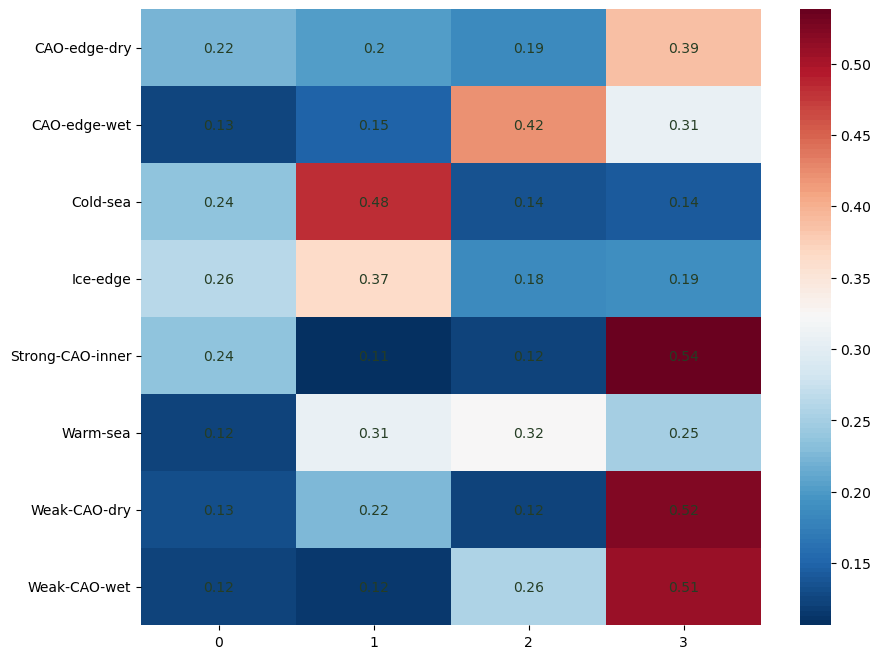

In [14]:
#标准化
#1 ['PBLH', 'RH', 'Thickness', 'LPV']

candidate_columns = ['Thickness','TropTheta', 'LPV','PBLH','PVA','CAODepth','LHRR','CAO500','GrdThick','ThickAdv',  'SHF', 'LHF','RH','ShearAngle', 'N2', 'SST']
chosed_columns  = ['LPV', 'LHRR', 'TropTheta', 'Thickness', 'CAPE','RH'] 
#chosed_columns = 
scaler = TimeSeriesScalerMeanVariance()
# features_standardized = feature_stage.groupby('ID')[chosed_columns].apply(sample_standardize_group).reset_index(drop=True)
# time_series = features_standardized.values.reshape(-1,stage_num,len(chosed_columns))
# X_normalized = time_series.copy()
time_series = feature_stage[chosed_columns].values.reshape(-1,stage_num,len(chosed_columns))
# 按每个时间点做均值和方差归一化
X_normalized = scaler.fit_transform(time_series) 
X_normalized[np.isnan(X_normalized)] = 0
n_clusters = 4
model = TimeSeriesKMeans(
    n_clusters=n_clusters,
    metric="euclidean",  # 使用动态时间规整
    n_init=5,      # 用不同质心初始值运行次数，增加以避免局部最优
    random_state=654 # 设置随机种子保证结果可重现
)
# 执行聚类
labels = model.fit_predict(X_normalized)
# 获取每个样本所属的簇标签
labels = model.labels_  # 或者使用之前 fit_predict 返回的 labels
# 获取每个簇的质心，形状为 (n_clusters, n_timestamps, n_features)
#----------------------------------------------------------
cluster_centers = model.cluster_centers_
unique_IDs = np.sort(np.unique(feature_stage.ID.values))
series_dict = {}
for cluster_idx in np.unique(labels):
    cluster_mask = (labels == cluster_idx)
    series_dict[cluster_idx] = unique_IDs[cluster_mask]
series_map = pd.DataFrame(index=class_dict.keys(),columns=series_dict.keys())
for index in class_dict.keys():
    for column in series_dict.keys():
        series_map.loc[index,column] = len(np.intersect1d(class_dict[index],series_dict[column]))
series_map = np.round(series_map/(series_map.sum(axis=1).values.reshape(-1,1)))
major_fraction = series_map.apply(lambda row: sum(row.values[np.argsort(row)][-2:]), axis=1).mean()
series_map = pd.DataFrame(index=class_dict.keys(),columns=series_dict.keys())
for index in class_dict.keys():
    for column in series_dict.keys():
        series_map.loc[index,column] = len(np.intersect1d(class_dict[index],series_dict[column]))
series_map = np.round(series_map/(series_map.sum(axis=1).values.reshape(-1,1)))
fig, ax = plt.subplots(figsize=(10, 8))
f = sns.heatmap(data=series_map.astype('float'),
            cmap=cmaps.MPL_RdBu_r,
            annot=True,#图中数字文本显示
            annot_kws={'size':10,'weight':'normal', 'color':'#253D24'},#数字属性设置，例如字号、磅值、颜色            
        )
print(major_fraction)

In [15]:
feature_stage

,ID,stage,Vmax10m,CAODepth,Q,GrdThick,PBLH,SIC,SST,CAO500,...,ShearAngle,ThickAdv,QAdv,V500,V925,Thickness,SHF,LHF,CAPE,GrdSKT
0,1,1,13.730000,315.085890,0.921539,27.401825,1056.160579,0.714013,274.885984,-11.555226,...,32.039882,1.254184,-1.200025,14.258994,8.673751,5035.661112,278.489260,175.043616,16.766249,5.264146
1,1,2,16.238333,341.433909,0.940791,35.410849,1178.792355,0.150683,275.021468,-10.089685,...,28.330664,0.572943,-4.176095,15.503496,10.713946,5026.931099,376.832352,203.164087,20.335691,2.531699
2,1,3,18.875000,357.594653,0.867953,45.080501,1220.231745,0.000000,274.515163,-10.393317,...,32.731742,-9.644566,-6.487017,16.887370,13.283898,5008.079001,443.712761,271.684585,16.161122,1.774703
3,1,4,20.728000,339.634366,0.864817,48.324214,1183.862968,0.295668,273.467624,-11.189489,...,40.096313,-14.893456,-3.775194,14.596944,14.569940,5006.938760,409.153563,238.888911,13.020853,1.888955
4,1,5,20.876667,317.257120,0.858826,54.475552,1166.064386,4.566661,272.723363,-10.776906,...,71.129994,-1.203476,1.181728,11.336769,16.266627,4997.823777,490.372261,223.398093,13.332215,4.245859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41843,50970,5,34.760000,157.909597,2.006674,72.089916,1611.166691,12.090711,276.018200,-14.591978,...,102.387578,46.392617,20.447968,19.676816,35.382059,5212.746933,633.822441,564.440040,14.989196,5.502474
41844,50970,6,30.361250,257.563653,1.837478,45.722138,1560.917348,0.785585,277.293441,-8.581647,...,130.667449,7.427421,-0.704898,14.542658,23.495805,5161.042174,399.101311,414.334718,30.178996,4.653836
41845,50970,7,21.807000,285.514375,2.096825,24.581891,1261.548831,0.000000,278.898787,-5.181822,...,126.218332,4.046613,2.378349,10.319680,18.323996,5173.643683,192.719398,298.198382,27.148555,0.857609
41846,50970,8,17.117000,149.721818,2.311731,16.618948,1140.897059,0.000000,278.462605,-6.603440,...,34.614731,-4.551268,-1.753610,19.664137,16.656740,5208.798933,122.811257,232.240943,24.415319,4.024421


In [16]:
evolution_titles = {
    3: "Cold air modification",
    2: "Warm air modification",
    0: "Icy air offshore",
    1: "Ice face landfall"
}

In [17]:
ratio = 0.2

In [18]:
save_folder = os.path.join(class_folder,'series')
if not os.path.exists(save_folder):
    os.makedirs(save_folder)
for filename in os.listdir(save_folder):
    os.remove(os.path.join(save_folder, filename))
series_cyclones = []
for index in class_dict.keys():
    for column in series_dict.keys():
        chosed_IDs = np.intersect1d(class_dict[index],series_dict[column])
        datasets.loc[chosed_IDs,'with'] = str(index)+'_'+str(column)
        if series_map.loc[index,column]>ratio:
            series_cyclones.append(str(index)+'_'+str(column))
            np.savetxt(os.path.join(save_folder,f'{str(index)}_{str(column)}.txt'),chosed_IDs,fmt='%d')

In [19]:
plt.rcParams.update({
    'axes.titlesize': 'x-large',   # 控制 axes 标题的字体大小
    'axes.labelsize': 'medium',     # 控制 x 和 y 轴标签的字体大小
    'xtick.labelsize': 20,   # 控制 x 轴刻度标签的字体大小
    'ytick.labelsize': 20,   # 控制 y 轴刻度标签的字体大小
    'legend.fontsize': 'medium',    # 控制图例的字体大小
    'figure.titlesize': 'x-large', # 控制 figure 标题的字体大小
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    
})
mpl.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['text.usetex']  = False

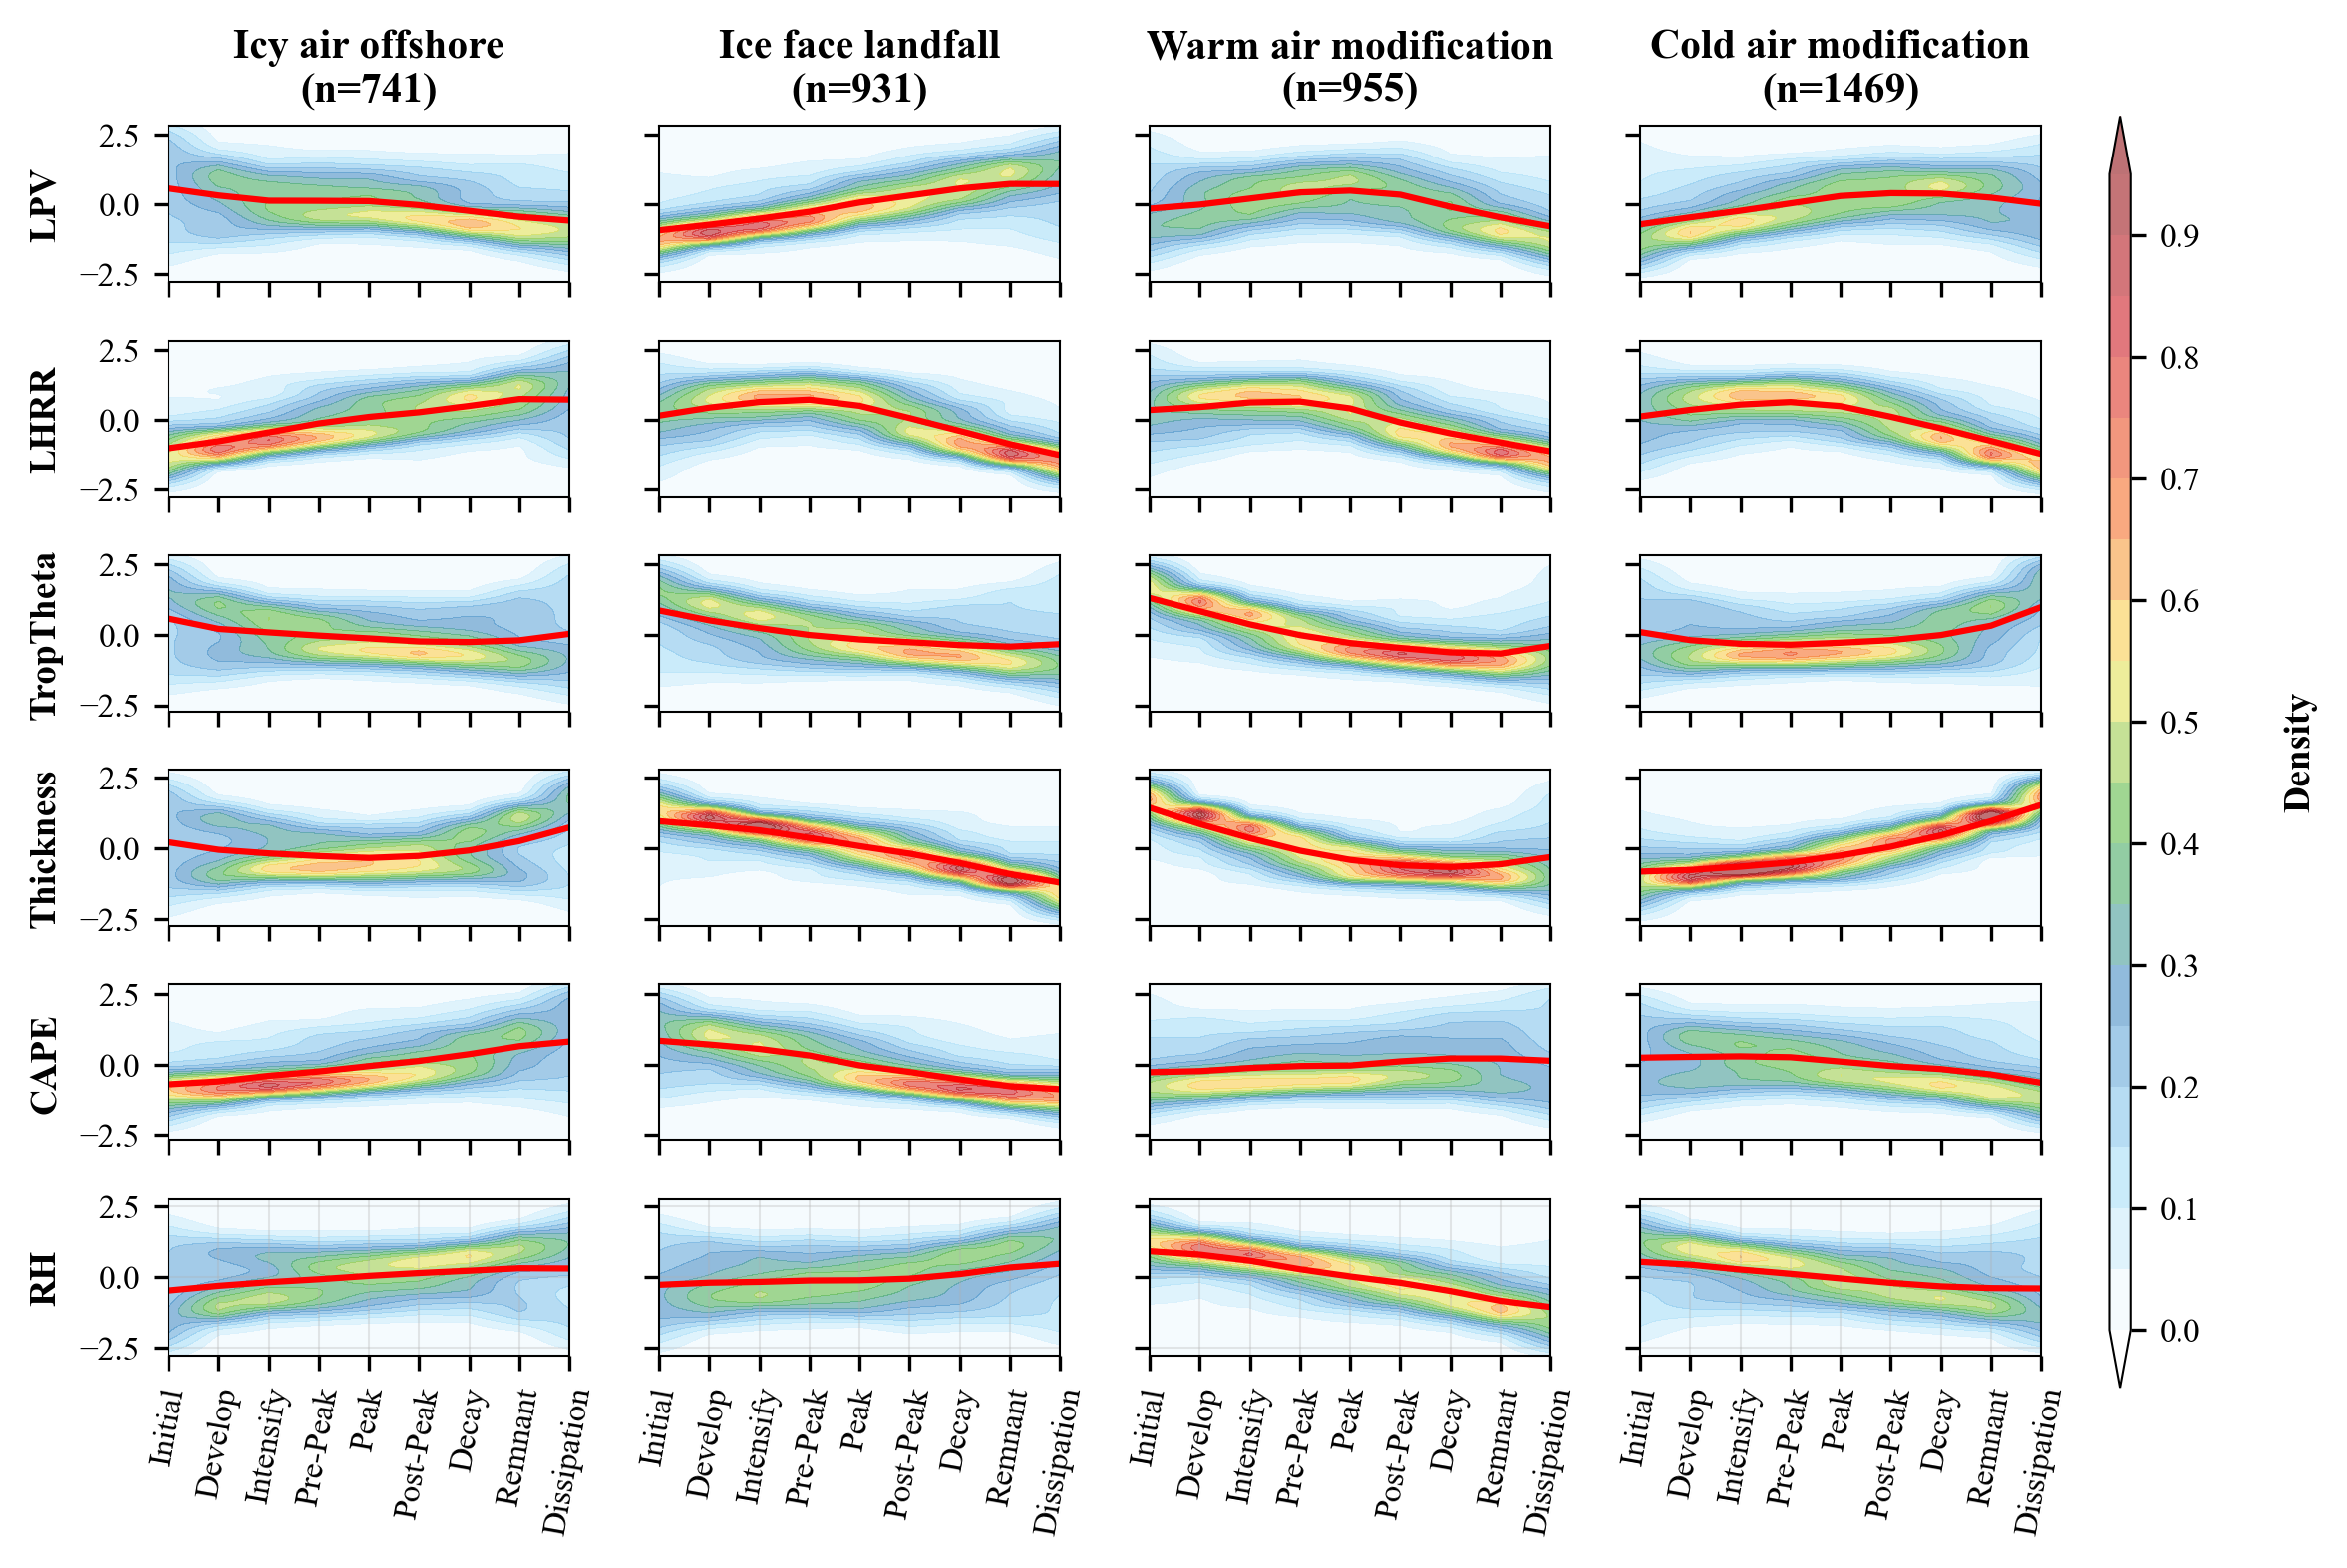

In [20]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np
import os

# ======================== 统一格式设置 ========================
# 原 figsize=(20,15) 英寸，宽高比 4:3 → 要求宽度 18 cm
WIDTH_CM = 18.0
HEIGHT_CM = WIDTH_CM * (15 / 20)   # = 13.5 cm
WIDTH_INCH = WIDTH_CM / 2.54        # ≈ 7.0866
HEIGHT_INCH = HEIGHT_CM / 2.54      # ≈ 5.315

plt.rcParams.update({
    'font.size': 9,                     # 基础字号
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'axes.linewidth': 0.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})

# 清理文件夹（原样保留）
chosed_folder = r'X:\TimeSeries'
for filename in os.listdir(chosed_folder):
    os.remove(os.path.join(chosed_folder, filename))

# 创建图形（使用统一物理尺寸）
fig, axes = plt.subplots(len(chosed_columns), n_clusters,
                         figsize=(WIDTH_INCH, HEIGHT_INCH),
                         sharex=True, sharey='row', dpi=300)

time_axis = np.arange(stage_num)

# 为所有子图添加完整黑色边框（遍历二维数组）
for ax_row in axes:
    for ax in ax_row:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color('black')

for cluster_idx in range(n_clusters):
    for feature_idx in range(len(chosed_columns)):
        ax = axes[feature_idx, cluster_idx]
        cluster_mask = (labels == cluster_idx)
        cluster_data = X_normalized[cluster_mask]
        
        n_time_points = len(time_axis)
        y_min = np.min(X_normalized[:, :, feature_idx])
        y_max = np.max(X_normalized[:, :, feature_idx])
        y_grid = np.linspace(y_min, y_max, 100)
        time_grid = time_axis
        density = np.zeros((len(y_grid), len(time_grid)))
        
        for t_idx, t in enumerate(time_grid):
            values_at_t = cluster_data[:, t, feature_idx]
            kde = gaussian_kde(values_at_t)
            density[:, t_idx] = kde(y_grid)
        
        # 密度热图（保持原 cmap 和 alpha）
        im = ax.contourf(time_grid, y_grid, density,
                         levels=np.arange(0, 1, 0.05), alpha=0.6,
                         cmap=cmaps.WhiteBlueGreenYellowRed, zorder=1, extend='both')
        
        # 绘制聚类中心
        centroid = cluster_centers[cluster_idx, :, feature_idx]
        ax.plot(time_axis, centroid, color='red', linewidth=1.5,  # 线宽减小
                label='Centroid')
        
        if feature_idx == 0:
            # 子图标题：字号 10pt 加粗
            ax.set_title(f'{evolution_titles[cluster_idx]}\n(n={np.sum(cluster_mask)})',
                         fontsize=10, fontweight='bold')
        
        if cluster_idx == 0:
            ax.set_ylabel(chosed_columns[feature_idx], fontsize=9, fontweight='bold')
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
    
    # 保存该聚类的 ID 列表（原样）
    np.savetxt(os.path.join(chosed_folder, f'{str(cluster_idx)}.txt'),
               unique_IDs[cluster_mask], fmt='%d')
    
    # 设置 x 轴（注意：原代码在循环外部只对最后一个轴生效，这里调整到循环内部对当前行的最后一个轴设置）
    # 实际上，原逻辑可能希望为每个聚类（每列）的底部子图设置 x 轴标签。这里保持原样但调整字号
    ax.set_xticks(np.arange(stage_num))
    stage_labels = ["Initial", "Develop", "Intensify", "Pre-Peak", "Peak",
                    "Post-Peak", "Decay", "Remnant", "Dissipation"]
    phases_map = dict(zip(list(range(1, len(stage_labels) + 1)), stage_labels))
    ax.set_xticklabels(stage_labels, rotation=80, fontsize=8)   # 刻度字号 8pt
    ax.grid(True, alpha=0.3, linewidth=0.5)

# 添加颜色条
plt.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([1, 0.12, 0.01, 0.8])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Density', rotation=90, labelpad=20, fontsize=9)   # 色标标签 9pt
plt.setp(cbar_ax.get_yticklabels(), rotation=0, fontsize=8)       # 色标刻度 7pt

# 保存图片（先 tight_layout 再 savefig）
plt.tight_layout()
output_path = r'D:\Desktop\PLs_feature\figures\time_series_clusters.png'
plt.savefig(output_path, dpi=300, bbox_inches="tight")

In [59]:
feature_unit = {'PVA':'1e-8 m**-1 s**-1','LPV':'PVU','Vort850':'1e-4 s**-1','Q':'g/kg','ano150km':'hPa','iso_r':'km',
                'LHRR':'W','Vmax10m':'m s**-1','vort10':'10 m**-1 s**-1','PBLH':'m','SIC':'%','CAO500':'K','ThickAdv':'m h**-1','GrdSKT':'1K 100km**-1',
                'CAODepth':'hPa','TropTheta':'K','level_trop':'hPa','SST':'K','GrdThick':'1m 100km**-1','shear_angle':'degree','Thickness':'km','LHF':'W m**-2','SHF':'W m**-2','heat':'W m**-2','N2':'s**-2','CAPE':'J kg**-1'
}
feature_unit = {
    'PVA': r'$\times10^{-8}$ $\mathrm{m}^{-1}\,\mathrm{s}^{-1}$',
    'LPV': r'$\mathrm{PVU}$',
    'Vort850': r'$\times10^{-4}$ $\mathrm{s}^{-1}$',
    'Q': r'$\mathrm{g}\,\mathrm{kg}^{-1}$',
    'LHRR': r'$\mathrm{W}\,\mathrm{m}^{-2}$',
    'Vmax10m': r'$\mathrm{m}\,\mathrm{s}^{-1}$',
    'vort10': r'$\zeta_{10}$ ($\times10^{-4}$ $\mathrm{s}^{-1}$)',
    'PBLH': r'$\mathrm{m}$',
    'SIC': r'$\%$',
    'CAO500': r'$\mathrm{K}$',
    'ThickAdv': r'$\mathrm{m}\,\mathrm{h}^{-1}$',
    'GrdSKT': r'$\mathrm{K}\,\mathrm{100km}^{-1}$',
    'CAODepth': r'$\mathrm{hPa}$',
    'TropTheta': r'$\mathrm{K}$',
    'level_trop': r'$\mathrm{hPa}$',
    'SST': r'$\mathrm{K}$',
    'GrdThick': r'$\mathrm{m}\,\mathrm{100km}^{-1}$',
    'shear_angle': r'$^{\circ}$',
    'Thickness': r'$\mathrm{km}$',
    'LHF': r'$\mathrm{W}\,\mathrm{m}^{-2}$',
    'SHF': r'$\mathrm{W}\,\mathrm{m}^{-2}$',
    'N2': r'$\mathrm{s}^{-2}$',
    'CAPE': r'$\mathrm{J}\,\mathrm{kg}^{-1}$',
    'GrdSKT': r'$\mathrm{K}\,\mathrm{100km}^{-1}$',
}
series_names = list(series_dict.keys())
# 英文名称
# 修改绘图函数以包含平均值线和单位标注（字号已调整）
def plot_single_subplot(ax, data, feature_name, color, y_limits, show_confidence=True, global_mean=True, linestyle='-'):
    """在单个子图上绘制特征演变（字号已统一为与正文协调）"""
    phases = ["Initial", "Develop", "Intensify", 
              "Pre-Peak", "Peak", "Post-Peak", 
              "Decay", "Remnant", "Dissipation"]
    data['phase'] = pd.Categorical(data["phase"], categories=phases, ordered=True)
    
    # 绘制线条（线宽、标记等略微调小）
    errorbar = ('ci', 99) if show_confidence else None

    sns.lineplot(data=data, x='phase', y=feature_name, color=color, err_style="bars",
                 errorbar=errorbar, linestyle=linestyle, dashes=False,
                 err_kws={'capsize': 1, 'capthick': 0.6, 'elinewidth': 0.7},
                 linewidth=1.2, markersize=3, markeredgewidth=0.5,
                 alpha=0.9, ax=ax)
    # 添加全局平均值横虚线
    if global_mean is not None:
        ax.axhline(y=global_mean, color='black', linestyle='--', linewidth=1,
                   alpha=0.7, label='Global Mean')
    
    # 设置y轴范围
    ax.set_ylim(y_limits[feature_name])
    
    # 添加垂直分隔线
    #for i in range(1, len(phases)):
        #ax.axvline(x=i-0.5, color='gray', linestyle=':', alpha=0.6, linewidth=0.5)
    
    # 设置标签（留空，由外部统一处理）
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    # 设置刻度（字号已由 rcParams 控制，但显式设置确保覆盖）
    ax.tick_params(axis='x', rotation=80, labelsize=8,pad=0)
    ax.tick_params(axis='y', labelsize=6,pad=0)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.2)
    
    # 移除自动生成的图例（避免重复）
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    # 添加完整黑色边框（保证所有子图边框一致）
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')



        #ax.set_title(f'{unit_text}',loc='left', fontweight='bold', fontsize=15, pad=-10)

In [33]:
area_features = ['Vmax10m','PBLH','LPV','CAPE','CAODepth','GrdThick','PVA', 'LHRR','SHF','LHF','Thickness','ThickAdv','TropTheta','Q','SST','SIC','Vort850'] 
stage_labels =  ["Initial", "Develop", "Intensify", 
        "Pre-Peak", "Peak", "Post-Peak", 
        "Decay", "Remnant", "Dissipation"]
phases_map = dict(zip(list(range(1,len(stage_labels)+1)),stage_labels))
features = feature_stage.copy()
features['phase']  = features['stage'].map(phases_map)
feature_long = features.groupby(['ID','phase'])[area_features].mean().reset_index()
for class_name in class_dict.keys():
    feature_long.loc[feature_long.ID.isin(class_dict[class_name]),'label'] = class_name
for column in series_dict.keys():
    feature_long.loc[feature_long.ID.isin(series_dict[column]),'series'] = column
#统计范围
y_limits = {}
for feature in area_features:
    all_values = []
    for series_name in series_dict.keys():
        chosed_pmcs_names = series_map.index[series_map[series_name] > ratio]
        chosed_data = feature_long[
            (feature_long.label.isin(chosed_pmcs_names)) & 
            (feature_long.ID.isin(series_dict[series_name]))
        ]
        all_values.extend(chosed_data[feature].dropna().tolist())

    y_limits[feature] = (np.quantile(all_values,0.1),np.quantile(all_values,0.9))
"""为所有标签分配固定的线条样式"""
line_styles = {
    'colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
}
class_names = list(class_dict.keys())
class_names.sort()
label_styles = {}
for i, label in enumerate(class_names):
    label_styles[label] = {
        'marker': 'o',
        'color': line_styles['colors'][i]
    }
# 预先计算所有特征的全局平均值
global_means = {}
for feature_name in area_features:
    global_means[feature_name] = np.nanmean(feature_long[feature_name])
label_styles  

{'CAO-edge-dry': {'marker': 'o', 'color': '#1f77b4'},
 'CAO-edge-wet': {'marker': 'o', 'color': '#ff7f0e'},
 'Cold-sea': {'marker': 'o', 'color': '#2ca02c'},
 'Ice-edge': {'marker': 'o', 'color': '#d62728'},
 'Strong-CAO-inner': {'marker': 'o', 'color': '#9467bd'},
 'Warm-sea': {'marker': 'o', 'color': '#8c564b'},
 'Weak-CAO-dry': {'marker': 'o', 'color': '#e377c2'},
 'Weak-CAO-wet': {'marker': 'o', 'color': '#7f7f7f'}}

In [23]:
letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)','(m)', '(n)', '(o)', '(p)', '(q)', '(r)', '(s)', '(t)', '(u)', '(v)', '(w)']

In [24]:
evolution_titles = {
    3: "Cold air modification",
    2: "Warm air modification",
    0: "Icy air offshore",
    1: "Ice face landfall"
}

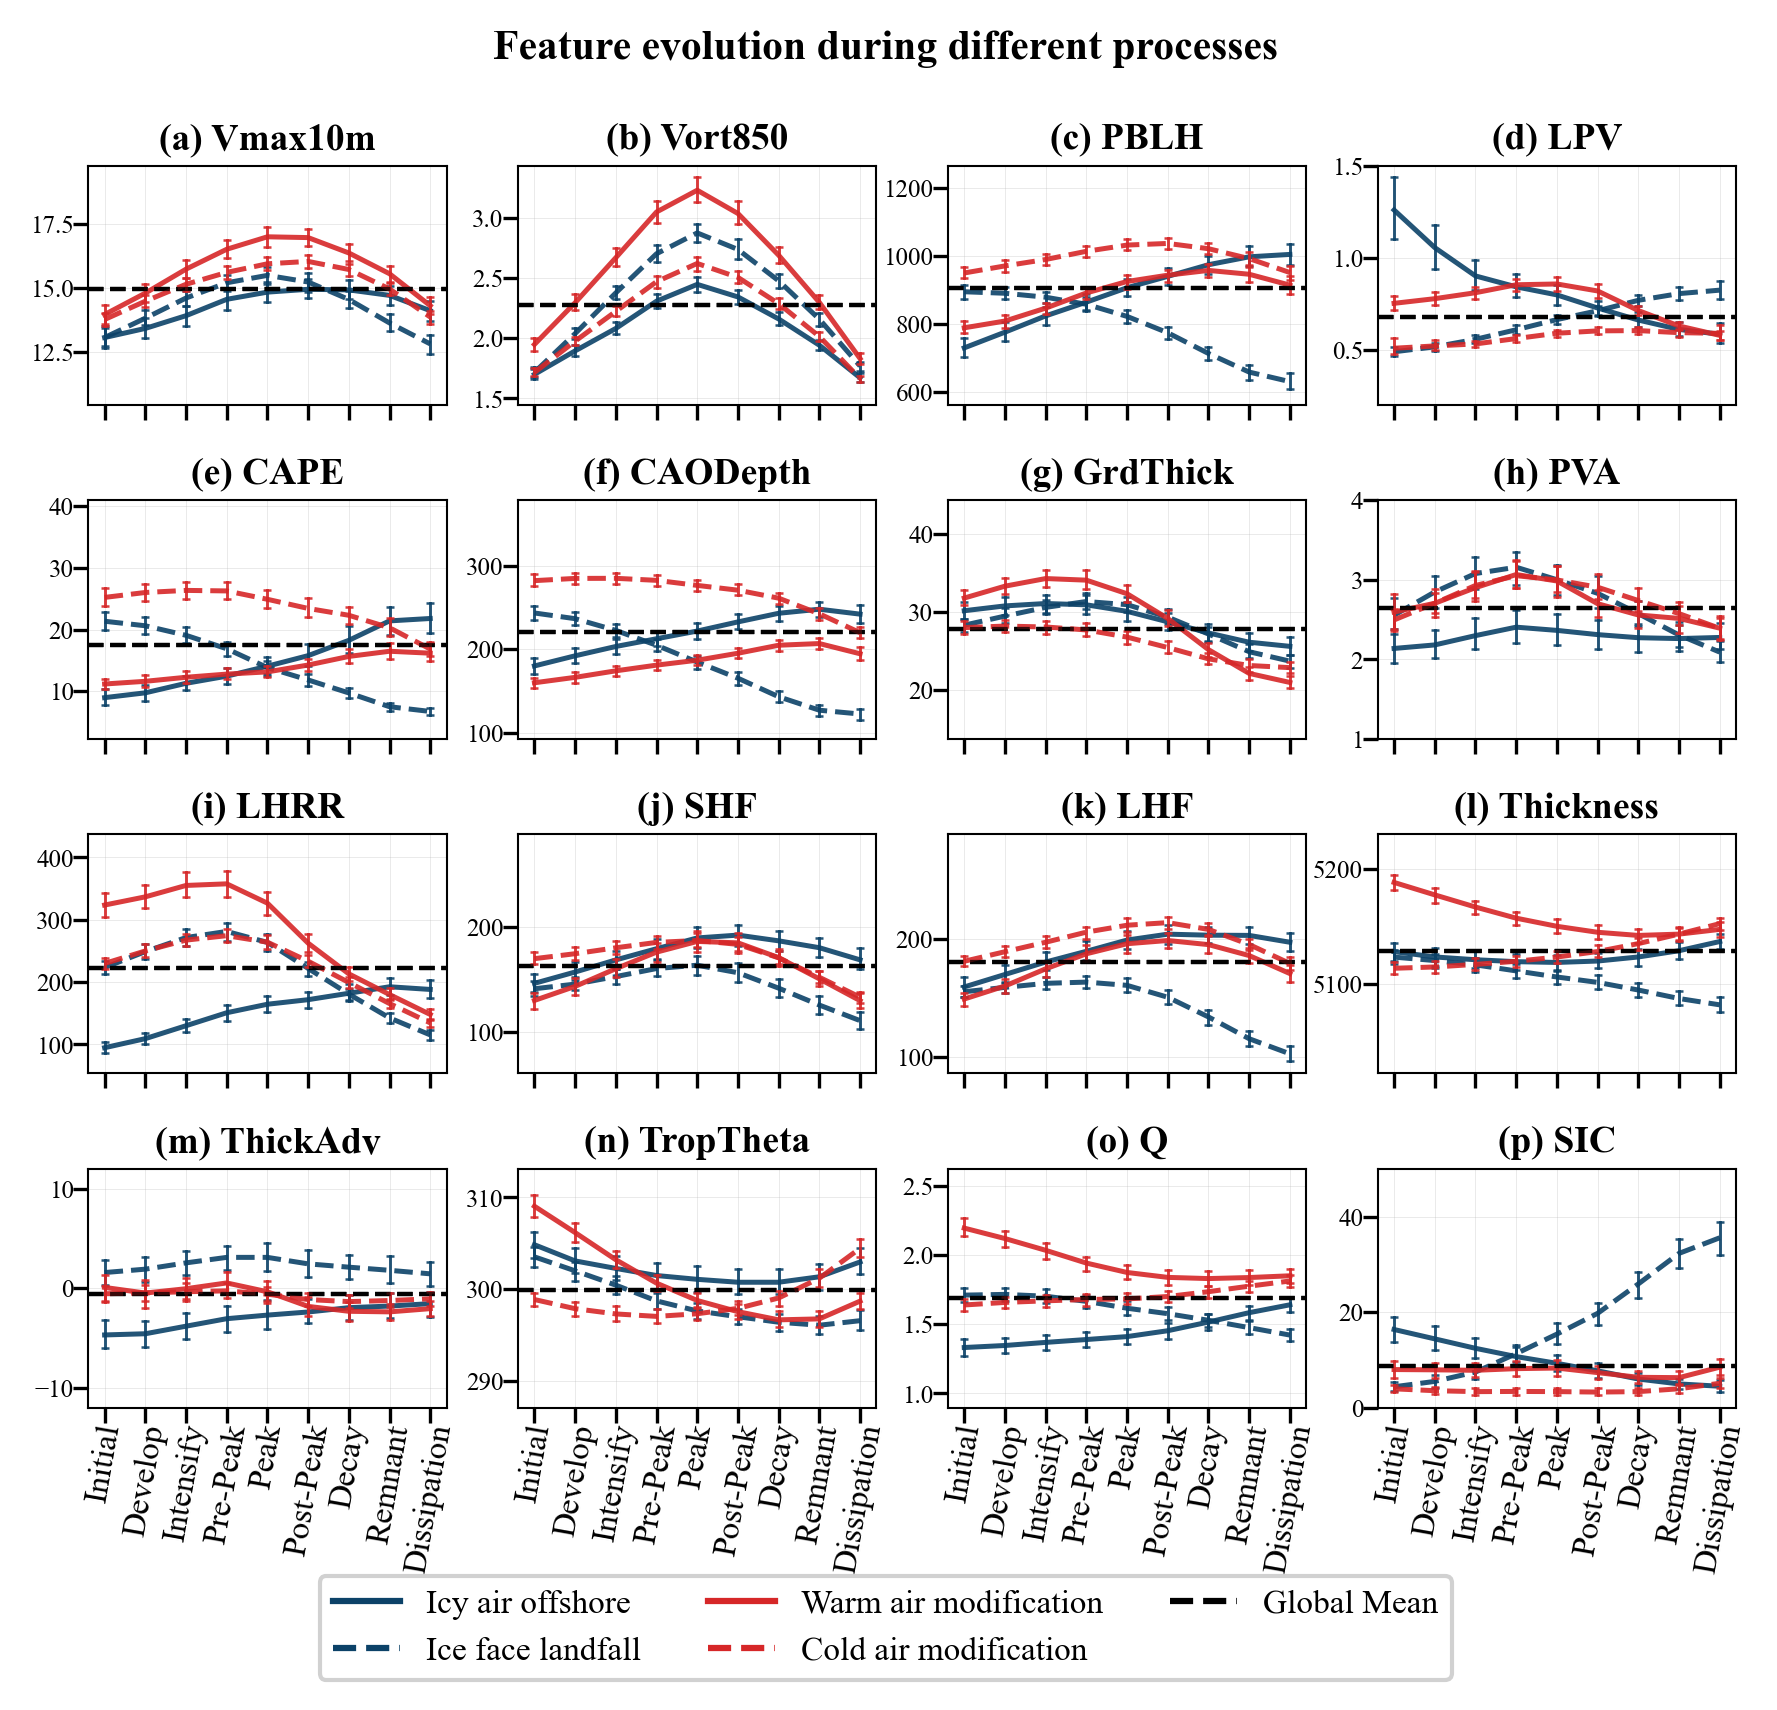

In [60]:
WIDTH_CM = 18.0
HEIGHT_CM = WIDTH_CM * (16 / 20)   # = 13.5 cm
WIDTH_INCH = WIDTH_CM / 2.54
HEIGHT_INCH = HEIGHT_CM / 2.54

plt.rcParams.update({
    'font.size': 9,                     # 基础字号 9pt
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11,
    'axes.linewidth': 0.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})
area_features = ['Vmax10m','Vort850','PBLH','LPV','CAPE','CAODepth','GrdThick','PVA', 'LHRR','SHF','LHF','Thickness','ThickAdv','TropTheta','Q','SIC']
# ======================== 主绘图部分 ========================
# 定义 y_limits（用户已提供部分，其余需补充完整）
y_limits['SIC'] = [0, 50]
y_limits['LPV'] = [0.2, 1.5]
y_limits['ThickAdv'] = [-12, 12]
y_limits['PVA'] = [1, 4]

# 创建图形（使用统一物理尺寸）
fig, axes = plt.subplots(4, 4, figsize=(WIDTH_INCH, HEIGHT_INCH), dpi=300, sharex=True)
fig.suptitle('Feature evolution during different processes', fontsize=10, fontweight='bold', y=0.96)

legend_elements = []
# 假设 series_dict 和 evolution_titles 已定义
for j, series_name in enumerate(series_dict.keys()):
    series_data = feature_long[(feature_long.ID.isin(series_dict[series_name]))]
    # 颜色与线型（原逻辑保留）
    if series_name == 0:
        color = "#0c4268"
        line_styles = '-'
    elif series_name == 1:
        color = "#0c4268"
        line_styles = '--'
    elif series_name == 2:
        color = "#d62728"
        line_styles = '-'
    elif series_name == 3:
        color = "#d62728"
        line_styles = '--'
    else:
        color = "#000000"
        line_styles = '-'
    
    # 遍历所有特征
    letters = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)',
               '(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)']  # 16个特征
    for i, feature_name in enumerate(area_features):
        row = i // 4
        col = i % 4
        ax = axes[row, col]
        # 绘制子图
        plot_single_subplot(ax, series_data, feature_name, color, y_limits,
                            True, global_means[feature_name], line_styles)
        # 设置子图标题（特征名称 + 字母编号）
        feature_display_name = letters[i] + ' ' + feature_name
        ax.set_title(feature_display_name, fontweight='bold', fontsize=9, pad=4)
        # 确保 y 轴刻度标签字号（已通过 rcParams 和 tick_params 设置）
    
    # 构建图例句柄
    element = plt.Line2D([0], [0], color=color, linestyle=line_styles,
                         linewidth=1.5, markersize=6, label=evolution_titles[series_name])
    legend_elements.append(element)

# 添加全局平均值图例
mean_element = plt.Line2D([0], [0], color='black', linestyle='--',
                          linewidth=1.5, label='Global Mean')
legend_elements.append(mean_element)

# 添加主图例（放置在底部中央，字号 8pt）
fig.legend(handles=legend_elements,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=3,
           fontsize=8,
           frameon=True,
           fancybox=True,
           shadow=False,   # shadow 可开可关，为简洁设为 False
           framealpha=0.9)

# 调整子图间距和底部空间
plt.subplots_adjust(hspace=0.4, wspace=0.2, bottom=0.15)

# 保存图片
output_path = r'D:\Desktop\PLs_feature\figures\feature_evolution_all.png'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()